In [3]:
import time
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torchvision.utils as vutils
import matplotlib.pyplot as plt
from contextlib import nullcontext

import helper

torch.backends.cudnn.benchmark = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_cuda = device.type == "cuda"

autocast_ctx = torch.cuda.amp.autocast if use_cuda else nullcontext
scaler = torch.cuda.amp.GradScaler(enabled=use_cuda)

device


device(type='cuda')

In [4]:
data_path = "../data/mnist_train.pt"
model_path = "../models/"
num_workers = 4

dataset = helper.MNISTPtDataset(data_path, normalize_range=(-1, 1))


In [5]:
batch_size = 512

loader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=use_cuda,
    drop_last=True,
    persistent_workers=(num_workers > 0),
)
len(loader)


117

In [ ]:
def _restore_rng(ckpt):
    # CPU RNG
    rng = ckpt.get("rng_torch", None)
    if rng is not None:
        try:
            # حالت درست: torch.ByteTensor روی CPU
            if isinstance(rng, torch.Tensor):
                rng = rng.detach().cpu()
                if rng.dtype != torch.uint8:
                    rng = rng.to(torch.uint8)
            else:
                # اگر bytes / list / ... بود
                rng = torch.tensor(rng, dtype=torch.uint8)

            torch.set_rng_state(rng)
        except Exception as e:
            print(f"[WARN] could not restore torch CPU RNG state: {e}")

    # CUDA RNG
    if torch.cuda.is_available():
        rng_cuda = ckpt.get("rng_cuda", None)
        if rng_cuda is not None:
            try:
                fixed = []
                for s in rng_cuda:
                    if isinstance(s, torch.Tensor):
                        s = s.detach().cpu()
                        if s.dtype != torch.uint8:
                            s = s.to(torch.uint8)
                    else:
                        s = torch.tensor(s, dtype=torch.uint8)
                    fixed.append(s)
                torch.cuda.set_rng_state_all(fixed)
            except Exception as e:
                print(f"[WARN] could not restore CUDA RNG state: {e}")


In [18]:
import os
import torch

os.makedirs("../models", exist_ok=True)

def save_full(path):
    ckpt = {
        "epoch": epoch,
        "z_dim": z_dim,
        "G_class": G.__class__.__name__,
        "D_class": D.__class__.__name__,
        "G_state": G.state_dict(),
        "D_state": D.state_dict(),
        "optG_state": optG.state_dict(),
        "optD_state": optD.state_dict(),
        "scaler_state": scaler.state_dict() if hasattr(scaler, "state_dict") else None,
        "batch_size": batch_size,
        "lr_g": lr_g,
        "lr_d": lr_d,
        "betas_G": optG.param_groups[0]["betas"],
        "betas_D": optD.param_groups[0]["betas"],
        "normalize_range": (-1, 1),
        "num_workers": num_workers,
        "data_path": data_path,
        "rng_torch": torch.get_rng_state(),
        "rng_cuda": torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None,
    }
    torch.save(ckpt, path)
    return path

def load_full(path="../models/cgan_mnist_full.pt", map_location=None):
    ckpt = torch.load(path, map_location=map_location if map_location is not None else device)

    G.load_state_dict(ckpt["G_state"])
    D.load_state_dict(ckpt["D_state"])
    optG.load_state_dict(ckpt["optG_state"])
    optD.load_state_dict(ckpt["optD_state"])

    if ckpt.get("scaler_state") is not None and hasattr(scaler, "load_state_dict"):
        scaler.load_state_dict(ckpt["scaler_state"])

    _restore_rng(ckpt)   # <-- این خط جایگزین torch.set_rng_state قبلی

    return ckpt



In [10]:
@torch.no_grad()
def show_all_classes(G, z_dim, device, n_per_class=1, fixed_z=None):
    """
    از هر کلاس (0..9) نمونه تولید می‌کند و نمایش می‌دهد.
    خروجی‌ها فرض شده در بازه [-1, 1] هستند.
    """
    G.eval()

    labels = torch.arange(10, device=device).repeat_interleave(n_per_class)  # (10*n_per_class,)
    n = labels.numel()

    if fixed_z is None:
        z = torch.randn(n, z_dim, device=device)
    else:
        z = fixed_z.to(device)
        assert z.shape == (n, z_dim), f"fixed_z باید شکل {(n, z_dim)} داشته باشد، ولی {z.shape} است."

    x = G(z, labels)  # (n, 1, 28, 28)

    # تبدیل از [-1,1] به [0,1] برای نمایش
    x = (x.clamp(-1, 1) + 1) / 2

    fig, axes = plt.subplots(1, 10, figsize=(14, 2))
    for c in range(10):
        idx = c * n_per_class  # اولین نمونه‌ی هر کلاس
        axes[c].imshow(x[idx, 0].detach().cpu().numpy(), cmap="gray")
        axes[c].set_title(str(c))
        axes[c].axis("off")

    plt.tight_layout()
    plt.show()


In [11]:
def show_gen_samples(G, n=3, z_dim=96):
    G.eval()
    with torch.no_grad():
        y = torch.randint(0, 10, (n,), device=device, dtype=torch.long)
        z = torch.randn(n, z_dim, device=device)
        x = G(z, y).detach().float().cpu()
        x = (x.clamp(-1, 1) + 1) / 2
        grid = vutils.make_grid(x, nrow=n, padding=2)
        plt.figure(figsize=(n * 2.2, 2.2))
        plt.axis("off")
        plt.imshow(grid.permute(1, 2, 0))
        plt.show()
    G.train()


In [12]:
class Generator(nn.Module):
    def __init__(self, z_dim=96, n_classes=10, emb_dim=32, ch=64):
        super().__init__()
        self.emb = nn.Embedding(n_classes, emb_dim)
        self.fc = nn.Linear(z_dim + emb_dim, ch * 7 * 7)

        self.net = nn.Sequential(
            nn.BatchNorm2d(ch),
            nn.SiLU(inplace=True),
            nn.ConvTranspose2d(ch, ch // 2, 4, 2, 1),
            nn.BatchNorm2d(ch // 2),
            nn.SiLU(inplace=True),
            nn.ConvTranspose2d(ch // 2, ch // 4, 4, 2, 1),
            nn.BatchNorm2d(ch // 4),
            nn.SiLU(inplace=True),
            nn.Conv2d(ch // 4, 1, 3, 1, 1),
            nn.Tanh(),
        )

    def forward(self, z, y):
        e = self.emb(y)
        x = torch.cat([z, e], dim=1)
        x = self.fc(x)
        x = x.view(x.size(0), -1, 7, 7)
        x = self.net(x)
        return x


class Discriminator(nn.Module):
    def __init__(self, n_classes=10, ch=64):
        super().__init__()
        self.emb = nn.Embedding(n_classes, 28 * 28)

        self.net = nn.Sequential(
            nn.Conv2d(2, ch, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ch, ch * 2, 4, 2, 1),
            nn.BatchNorm2d(ch * 2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ch * 2, ch * 4, 3, 2, 1),
            nn.BatchNorm2d(ch * 4),
            nn.LeakyReLU(0.2, inplace=True),
        )

        self.fc = nn.Linear(ch * 4 * 4 * 4, 1)

    def forward(self, x, y):
        y_map = self.emb(y).view(-1, 1, 28, 28)
        h = torch.cat([x, y_map], dim=1)
        h = self.net(h)
        h = h.view(h.size(0), -1)
        h = self.fc(h)
        return h.view(-1)


In [13]:
z_dim = 96

G = Generator(z_dim=z_dim, ch=64).to(device)
D = Discriminator(ch=64).to(device)

sum(p.numel() for p in G.parameters()), sum(p.numel() for p in D.parameters())


(446241, 441185)

In [15]:
criterion = nn.BCEWithLogitsLoss()

lr_g = 2e-4
lr_d = 2e-4

optG = torch.optim.Adam(G.parameters(), lr=lr_g, betas=(0.5, 0.999))
optD = torch.optim.Adam(D.parameters(), lr=lr_d, betas=(0.5, 0.999))

n_epochs = 30


epoch 001 | d_loss 0.4645 | g_loss 1.3590 | time 5.1s
epoch 002 | d_loss 0.5423 | g_loss 1.0658 | time 4.9s
epoch 003 | d_loss 0.5720 | g_loss 1.2437 | time 4.9s
epoch 004 | d_loss 0.5147 | g_loss 1.1826 | time 4.9s


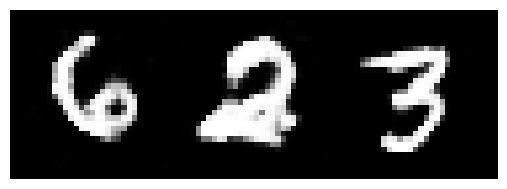

epoch 005 | d_loss 0.4974 | g_loss 1.3116 | time 4.9s
epoch 006 | d_loss 0.5468 | g_loss 1.4998 | time 4.9s
epoch 007 | d_loss 0.5505 | g_loss 1.3192 | time 4.9s
epoch 008 | d_loss 0.5219 | g_loss 1.4022 | time 4.9s
epoch 009 | d_loss 0.5005 | g_loss 1.3376 | time 4.9s


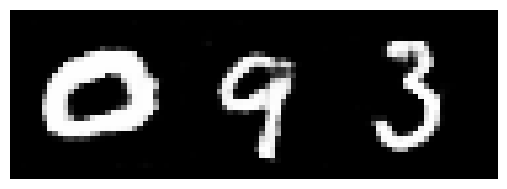

epoch 010 | d_loss 0.5388 | g_loss 1.1112 | time 4.9s
epoch 011 | d_loss 0.6284 | g_loss 1.3732 | time 4.9s
epoch 012 | d_loss 0.5574 | g_loss 1.4536 | time 4.9s
epoch 013 | d_loss 0.5678 | g_loss 1.2644 | time 5.0s
epoch 014 | d_loss 0.5255 | g_loss 1.3065 | time 5.0s


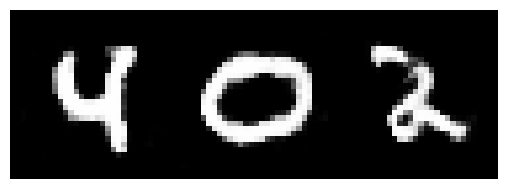

epoch 015 | d_loss 0.5705 | g_loss 1.3869 | time 4.9s
epoch 016 | d_loss 0.5302 | g_loss 1.3460 | time 5.0s
epoch 017 | d_loss 0.5543 | g_loss 1.3737 | time 4.9s
epoch 018 | d_loss 0.6090 | g_loss 1.3246 | time 5.0s
epoch 019 | d_loss 0.5119 | g_loss 1.2916 | time 5.0s


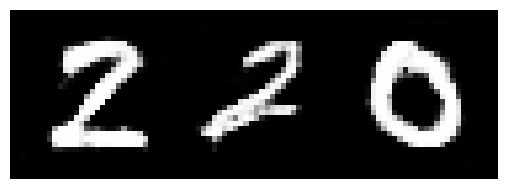

epoch 020 | d_loss 0.4828 | g_loss 1.2814 | time 5.0s
epoch 021 | d_loss 0.5309 | g_loss 1.1460 | time 5.0s
epoch 022 | d_loss 0.4798 | g_loss 1.0070 | time 5.0s
epoch 023 | d_loss 0.4839 | g_loss 1.3050 | time 5.0s
epoch 024 | d_loss 0.5516 | g_loss 1.3365 | time 5.0s


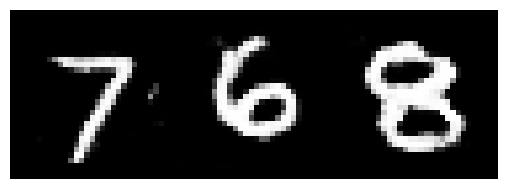

epoch 025 | d_loss 0.4434 | g_loss 1.2279 | time 5.0s
epoch 026 | d_loss 0.5250 | g_loss 1.3062 | time 5.0s
epoch 027 | d_loss 0.5818 | g_loss 1.1121 | time 5.0s
epoch 028 | d_loss 0.5685 | g_loss 1.3597 | time 5.0s
epoch 029 | d_loss 0.5200 | g_loss 1.1203 | time 5.0s


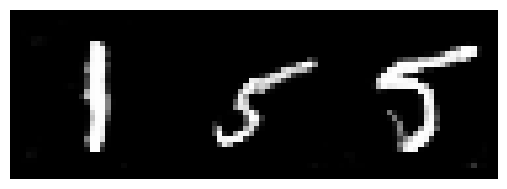

epoch 030 | d_loss 0.5272 | g_loss 1.1647 | time 5.0s


In [52]:
for epoch in range(1, n_epochs + 1):
    G.train()
    D.train()

    t0 = time.time()
    g_loss_ema = None
    d_loss_ema = None

    for batch in loader:
        x, y = batch[0], batch[1]
        x = x.to(device, non_blocking=True).float()
        y = y.to(device, non_blocking=True).long().view(-1)

        bsz = x.size(0)
        real_target = torch.ones(bsz, device=device)
        fake_target = torch.zeros(bsz, device=device)

        z = torch.randn(bsz, z_dim, device=device)
        y_fake = torch.randint(0, 10, (bsz,), device=device, dtype=torch.long)

        with autocast_ctx():
            x_fake = G(z, y_fake)
            real_logits = D(x, y)
            fake_logits = D(x_fake.detach(), y_fake)
            d_loss_real = criterion(real_logits, real_target)
            d_loss_fake = criterion(fake_logits, fake_target)
            d_loss = 0.5 * (d_loss_real + d_loss_fake)

        optD.zero_grad(set_to_none=True)
        scaler.scale(d_loss).backward()
        scaler.step(optD)
        scaler.update()

        z = torch.randn(bsz, z_dim, device=device)
        y_fake = torch.randint(0, 10, (bsz,), device=device, dtype=torch.long)

        with autocast_ctx():
            x_fake = G(z, y_fake)
            fake_logits = D(x_fake, y_fake)
            g_loss = criterion(fake_logits, real_target)

        optG.zero_grad(set_to_none=True)
        scaler.scale(g_loss).backward()
        scaler.step(optG)
        scaler.update()

        dl = float(d_loss.detach().float().cpu())
        gl = float(g_loss.detach().float().cpu())
        d_loss_ema = dl if d_loss_ema is None else (0.95 * d_loss_ema + 0.05 * dl)
        g_loss_ema = gl if g_loss_ema is None else (0.95 * g_loss_ema + 0.05 * gl)

    if epoch % 5 == 0:
        show_gen_samples(G, n=3, z_dim=z_dim)

    dt = time.time() - t0
    print(f"epoch {epoch:03d} | d_loss {d_loss_ema:.4f} | g_loss {g_loss_ema:.4f} | time {dt:.1f}s")


In [75]:
save_full(f"{model_path}cgan-MNIST.pt")

'../models/cgan-MNIST.pt'

In [23]:
cGAN = load_full(f"{model_path}cgan-MNIST.pt")
G.load_state_dict(cGAN["G_state"])

<All keys matched successfully>

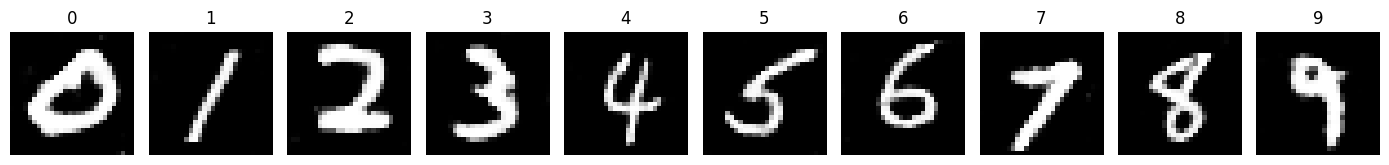

In [28]:
show_all_classes(G, z_dim=z_dim, device=device, n_per_class=1)
